In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn import metrics

X_train, y_train, X_test, y_test = joblib.load("../data/processed_data.pkl")
best_model = joblib.load("../models/best_model.pkl")

y_prob = best_model.predict_proba(X_test)[:, 1]
print("Loaded model and predictions")

Loaded model and predictions


In [2]:
# Business cost assumptions (adjust based on your scenario):
# - Missing a fraud (False Negative): ₹5,000 loss per transaction
# - False alarm on a legit txn (False Positive): ₹50 cost (customer friction, support call)

COST_FN = 5000   # cost of missing a fraud
COST_FP = 50     # cost of false alarm

print("Cost matrix:")
print(f"  False Negative (missed fraud): ₹{COST_FN:,}")
print(f"  False Positive (false alarm):  ₹{COST_FP:,}")
print(f"  Cost ratio FN:FP = {COST_FN//COST_FP}:1")

Cost matrix:
  False Negative (missed fraud): ₹5,000
  False Positive (false alarm):  ₹50
  Cost ratio FN:FP = 100:1


In [3]:
thresholds = np.arange(0.01, 1.0, 0.01)
costs = []
fp_counts = []
fn_counts = []

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred_t).ravel()

    total_cost = (fn * COST_FN) + (fp * COST_FP)
    costs.append(total_cost)
    fp_counts.append(fp)
    fn_counts.append(fn)

costs = np.array(costs)
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]

print(f"\n✅ Optimal business threshold: {optimal_threshold:.2f}")
print(f"   Total cost at optimal threshold: ₹{costs[optimal_idx]:,.0f}")
print(f"   False Negatives: {fn_counts[optimal_idx]}")
print(f"   False Positives: {fp_counts[optimal_idx]}")


✅ Optimal business threshold: 0.39
   Total cost at optimal threshold: ₹61,850
   False Negatives: 12
   False Positives: 37


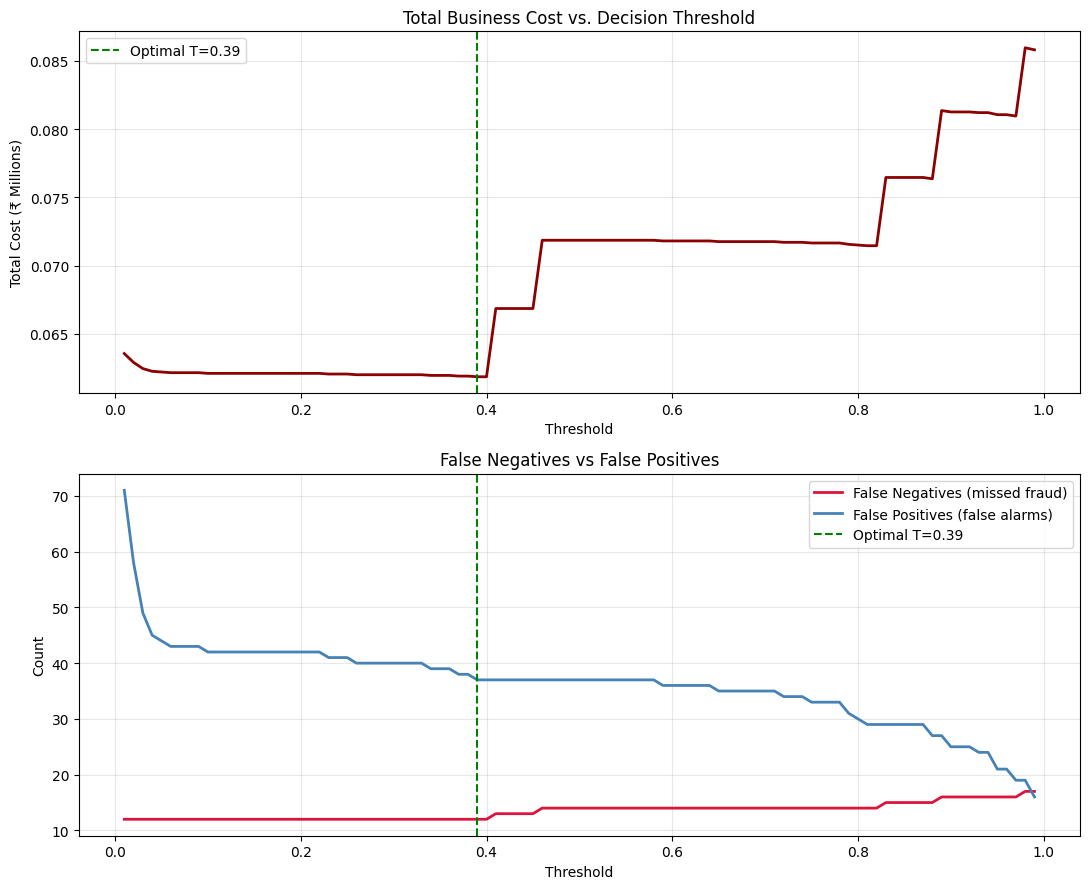

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9))

# Plot 1: Total business cost
axes[0].plot(thresholds, costs / 1e6, color="darkred", linewidth=2)
axes[0].axvline(optimal_threshold, color="green", linestyle="--",
                label=f"Optimal T={optimal_threshold:.2f}")
axes[0].set_title("Total Business Cost vs. Decision Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Total Cost (₹ Millions)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: FP vs FN tradeoff
axes[1].plot(thresholds, fn_counts, label="False Negatives (missed fraud)",
             color="crimson", linewidth=2)
axes[1].plot(thresholds, fp_counts, label="False Positives (false alarms)",
             color="steelblue", linewidth=2)
axes[1].axvline(optimal_threshold, color="green", linestyle="--",
                label=f"Optimal T={optimal_threshold:.2f}")
axes[1].set_title("False Negatives vs False Positives")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../models/cost_threshold.png", dpi=150)
plt.show()

In [5]:
# Youden's J threshold — maximises (TPR - FPR) on the ROC curve
fp_r, tp_r, t_vals = metrics.roc_curve(y_test, y_prob)
geo_idx = np.argmax(tp_r - fp_r)
geo_threshold = t_vals[geo_idx]

print("=" * 55)
print(f"{'Threshold Type':<25} {'Value':>8} {'Cost':>15}")
print("-" * 55)

for name, t in [("Default (0.5)", 0.5),
                ("Youden's J (ROC)", geo_threshold),
                ("Business-Optimal", optimal_threshold)]:
    y_pred_t = (y_prob > t).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred_t).ravel()
    cost = fn * COST_FN + fp * COST_FP
    print(f"{name:<25} {t:>8.2f} ₹{cost:>13,.0f}")

print("=" * 55)

Threshold Type               Value            Cost
-------------------------------------------------------
Default (0.5)                 0.50 ₹       71,850
Youden's J (ROC)              0.00 ₹       62,400
Business-Optimal              0.39 ₹       61,850


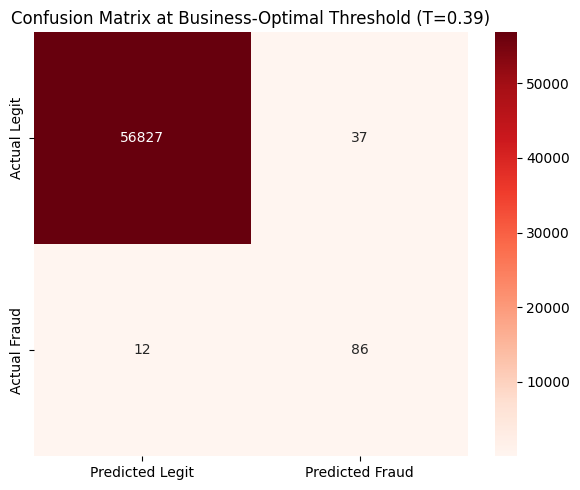

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.70      0.88      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.94      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [6]:
import seaborn as sns

y_pred_opt = (y_prob > optimal_threshold).astype(int)
cm = metrics.confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Predicted Legit", "Predicted Fraud"],
            yticklabels=["Actual Legit", "Actual Fraud"])
plt.title(f"Confusion Matrix at Business-Optimal Threshold (T={optimal_threshold:.2f})")
plt.tight_layout()
plt.savefig("../models/final_confusion_matrix.png", dpi=150)
plt.show()

print(metrics.classification_report(y_test, y_pred_opt,
                                     target_names=["Legitimate", "Fraud"]))

In [7]:
joblib.dump(optimal_threshold, "../models/optimal_threshold.pkl")
print(f"Saved optimal threshold: {optimal_threshold:.2f}")

Saved optimal threshold: 0.39
